<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Binding_Energy_Reconstruction_V2_Alpha_Closure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Binding-Energy Reconstruction V2 — Alpha / Helium Closure Refinement

**Purpose:** test whether an ECSM response-cost functional can reconstruct the AME2020 nuclear binding-energy curve, with V2 adding explicit light-nucleus and alpha/helium closure terms.

This notebook is designed as a GitHub/paper evidence notebook. It loads AME2020 CSV data, standardises the nuclear columns, fits response-cost-inspired feature models, compares V1-style and V2 alpha-closure models, exports figures/tables, and writes a final verdict JSON.

Main target:

\[
(A,Z)
ightarrow \mathcal{C}_N(A,Z)
ightarrow B(A,Z)/A
\]

V2 question:

> Does adding alpha/helium closure terms improve the light-nucleus region while preserving the broad iron/Ni binding ridge?


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CELL 01 — SETUP

from pathlib import Path
import json
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

OUT = Path("ecsm_binding_energy_reconstruction_v2_alpha_closure_out")
DATA = OUT / "data"
FIG = OUT / "figures"
TAB = OUT / "tables"
for p in [OUT, DATA, FIG, TAB]:
    p.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUT.resolve())
print("Random seed:", RANDOM_SEED)


Output directory: /content/ecsm_binding_energy_reconstruction_v2_alpha_closure_out
Random seed: 42


In [5]:
# CELL 02 — LOAD AME2020 CSV

# Preferred Colab path supplied by Adam.
AME_CSV_CANDIDATES = [
    Path("/content/drive/MyDrive/ame2020.csv"),
    Path("/content/ame2020.csv"),
    Path("ame2020.csv"),
    Path("/mnt/data/ame2020.csv"),
]

AME_CSV_PATH = None
for candidate in AME_CSV_CANDIDATES:
    if candidate.exists():
        AME_CSV_PATH = candidate
        break

if AME_CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find ame2020.csv. Upload it to Colab or place it at /content/drive/MyDrive/ame2020.csv"
    )

ame = pd.read_csv(AME_CSV_PATH)
print("Loaded AME2020 CSV:", AME_CSV_PATH)
print("Shape:", ame.shape)
print("Columns:")
print(list(ame.columns))

display(ame.head())

Loaded AME2020 CSV: /content/drive/MyDrive/ame2020.csv
Shape: (3378, 104)
Columns:
['nucid', 'n', 'z', 'mass_excess', 'mass_excess_num', 'mass_excess_unc', 'mass_excess_sys', 'mass_excess_round', 'mass_excess_round_unc', 'binding', 'binding_num', 'binding_unc', 'binding_sys', 'binding_round', 'binding_round_unc', 'beta_decay_en_round', 'beta_decay_en_round_unc', 'beta_decay_en', 'beta_decay_en_num', 'beta_decay_en_unc', 'beta_decay_en_sys', 'atomic_mass', 'atomic_mass_num', 'atomic_mass_unc', 'atomic_mass_sys', 'atomic_mass_round', 'atomic_mass_round_unc', 's2n', 's2n_num', 's2n_unc', 's2n_round', 's2n_round_unc', 's2n_sys', 's2p', 's2p_num', 's2p_unc', 's2p_round', 's2p_round_unc', 's2p_sys', 'qa', 'qa_num', 'qa_unc', 'qa_round', 'qa_round_unc', 'qa_sys', 'q2bm', 'q2bm_num', 'q2bm_unc', 'q2bm_round', 'q2bm_round_unc', 'q2bm_sys', 'qep', 'qep_num', 'qep_unc', 'qep_round', 'qep_round_unc', 'qep_sys', 'qbmn', 'qbmn_num', 'qbmn_unc', 'qbmn_round', 'qbmn_round_unc', 'qbmn_sys', 'sn', 'sn_n

,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qna_num,qna_unc,qna_round,qna_round_unc,qna_sys,qec_num,qec_unc,qec_round,qec_round_unc,qec
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,0,1,7288.971064,7288.971064,0.000013,N,7288.97106,0.00001,0.00000,...,NaN,NaN,NaN,NaN,NaN,-782.347,0.0,-782.347,0.0,-782.347
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.28310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.26540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3HE,1,2,14931.218880,14931.218880,0.000060,N,14931.21888,0.00006,2572.68044,...,NaN,NaN,20577.6189,0.0005,NaN,-18.592,0.0,-18.592,0.0,-18.592


In [6]:
# CELL 03 — STANDARDISE AME2020 COLUMNS

df = ame.copy()

required = ["n", "z", "binding"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"AME CSV is missing required columns: {missing}")

df["A"] = pd.to_numeric(df["n"], errors="coerce") + pd.to_numeric(df["z"], errors="coerce")
df["N"] = pd.to_numeric(df["n"], errors="coerce")
df["Z"] = pd.to_numeric(df["z"], errors="coerce")

# AME CSV binding column is binding energy per nucleon in keV.
df["B_per_A_keV"] = pd.to_numeric(df["binding"], errors="coerce")
df["B_per_A_MeV"] = df["B_per_A_keV"] / 1000.0

# Standard name used by later cells.
df["BE_per_A_MeV"] = df["B_per_A_MeV"]

df = df.dropna(subset=["A", "Z", "N", "BE_per_A_MeV"]).copy()
df[["A", "Z", "N"]] = df[["A", "Z", "N"]].astype(int)

print("Parsed nuclides:", len(df))
print("A range:", int(df.A.min()), int(df.A.max()))
print("Z range:", int(df.Z.min()), int(df.Z.max()))

display(df[["nucid", "A", "Z", "N", "BE_per_A_MeV"]].head(12))


Parsed nuclides: 3378
A range: 1 295
Z range: 0 118


,nucid,A,Z,N,BE_per_A_MeV
0,1N,1,0,1,0.000000
1,1H,1,1,0,0.000000
2,2H,2,1,1,1.112283
3,3H,3,1,2,2.827265
4,3HE,3,2,1,2.572680
5,3LI,3,3,0,-2.267000
6,4H,4,1,3,1.720449
7,4HE,4,2,2,7.073916
8,4LI,4,3,1,1.153760
9,5H,5,1,4,1.336359


In [7]:
# CELL 04 — CLEAN ANALYSIS SAMPLE AND MOST-BOUND RIDGE

work = df.copy()
work = work[np.isfinite(work["BE_per_A_MeV"])]
work = work[work["BE_per_A_MeV"] >= -0.1]
work = work[work["A"] >= 1].copy()
work["is_extrapolated_like"] = False

summary = {
    "n_rows_all": int(len(df)),
    "n_rows_work": int(len(work)),
    "A_min": int(work.A.min()),
    "A_max": int(work.A.max()),
    "Z_min": int(work.Z.min()),
    "Z_max": int(work.Z.max()),
    "BEA_min_MeV": float(work.BE_per_A_MeV.min()),
    "BEA_max_MeV": float(work.BE_per_A_MeV.max()),
}

with open(OUT / "dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

idx = work.groupby("A")["BE_per_A_MeV"].idxmax()
ridge = work.loc[idx].sort_values("A").copy()
ridge.to_csv(TAB / "ame2020_most_bound_by_A.csv", index=False)

print("Top observed B/A ridge nuclei:")
display(ridge.sort_values("BE_per_A_MeV", ascending=False)[["nucid", "A", "Z", "N", "BE_per_A_MeV"]].head(20))
print("Saved ridge table:", TAB / "ame2020_most_bound_by_A.csv")


{
  "n_rows_all": 3378,
  "n_rows_work": 3376,
  "A_min": 1,
  "A_max": 295,
  "Z_min": 0,
  "Z_max": 118,
  "BEA_min_MeV": 0.0,
  "BEA_max_MeV": 8.7945555
}
Top observed B/A ridge nuclei:


,nucid,A,Z,N,BE_per_A_MeV
557,62NI,62,28,34,8.794555
510,58FE,58,26,32,8.792253
488,56FE,56,26,30,8.790356
534,60NI,60,28,32,8.780777
462,54CR,54,24,30,8.777967
581,64NI,64,28,36,8.777464
439,52CR,52,24,28,8.775995
499,57FE,57,26,31,8.770283
521,59CO,59,27,32,8.768038
546,61NI,61,28,33,8.765028


Saved ridge table: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/tables/ame2020_most_bound_by_A.csv


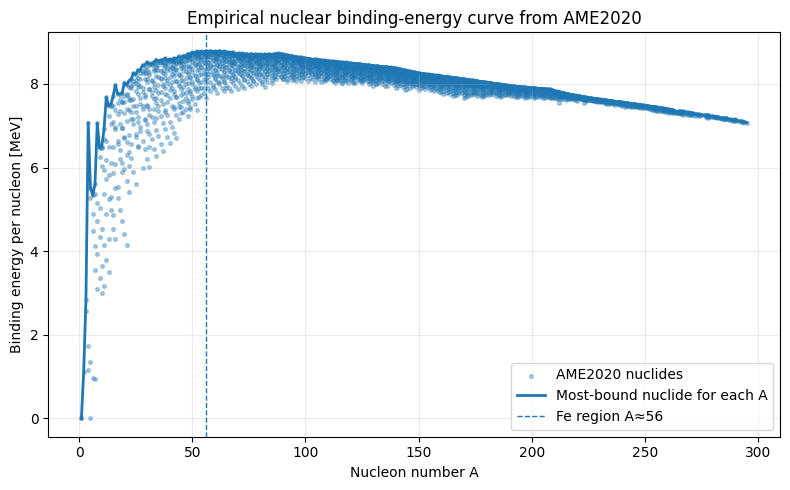

Saved: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/figures/fig01_empirical_binding_curve.png


In [8]:
# CELL 05 — FIGURE 1: EMPIRICAL BINDING-ENERGY CURVE

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(work["A"], work["BE_per_A_MeV"], s=7, alpha=0.35, label="AME2020 nuclides")
ax.plot(ridge["A"], ridge["BE_per_A_MeV"], linewidth=2, label="Most-bound nuclide for each A")
ax.axvline(56, linestyle="--", linewidth=1, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Binding energy per nucleon [MeV]")
ax.set_title("Empirical nuclear binding-energy curve from AME2020")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig01_empirical_binding_curve.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig01_empirical_binding_curve.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)


In [9]:
# CELL 06 — RESPONSE-COST FEATURE BUILDERS

MAGIC_NUMBERS = np.array([2, 8, 20, 28, 50, 82, 126], dtype=float)

def nearest_magic_distance(x):
    x = np.asarray(x, dtype=float)
    return np.min(np.abs(x[:, None] - MAGIC_NUMBERS[None, :]), axis=1)


def make_features(dataframe, model_kind="base"):
    # Build response-cost-inspired features.
    # The target is observed binding energy per nucleon. Positive feature weights may be
    # interpreted as lowering effective response cost. Negative terms encode burden-like
    # contributions after fitting.
    A = dataframe["A"].to_numpy(dtype=float)
    Z = dataframe["Z"].to_numpy(dtype=float)
    N = dataframe["N"].to_numpy(dtype=float)
    eps = 1e-12

    feats = {
        # V1 / liquid-drop-like ECSM response-cost scaffold.
        "surface_localisation_penalty": -A ** (-1.0 / 3.0),
        "charge_separation_burden": -Z * np.maximum(Z - 1.0, 0.0) / (A ** (4.0 / 3.0) + eps),
        "isospin_mismatch_burden": -((N - Z) ** 2) / (A ** 2 + eps),
        "pairing_closure": np.where(
            ((Z % 2 == 0) & (N % 2 == 0)), 1.0,
            np.where(((Z % 2 == 1) & (N % 2 == 1)), -1.0, 0.0)
        ) / np.sqrt(A + eps),
    }

    if model_kind in ["v2_alpha_closure", "v2_alpha_magic"]:
        # Explicit alpha / helium closure terms for the light-nucleus region.
        feats.update({
            "helium4_exact_closure": np.exp(
                -((A - 4.0) / 1.0) ** 2
                -((Z - 2.0) / 0.65) ** 2
                -((N - 2.0) / 0.65) ** 2
            ),
            "alpha_like_N_eq_Z_even_even": (
                ((A % 4 == 0) & (Z == N) & (Z % 2 == 0) & (N % 2 == 0)).astype(float)
                / np.sqrt(A + eps)
            ),
            "light_alpha_cluster_window": np.exp(-((A - 4.0) / 7.0) ** 2) * np.exp(-((N - Z) / 2.0) ** 2),
            "deuteron_partial_closure": np.exp(
                -((A - 2.0) / 0.8) ** 2
                -((Z - 1.0) / 0.6) ** 2
                -((N - 1.0) / 0.6) ** 2
            ),
        })

    if model_kind == "v2_alpha_magic":
        dZ = nearest_magic_distance(Z)
        dN = nearest_magic_distance(N)
        feats.update({
            "magic_Z_closure": np.exp(-(dZ / 2.5) ** 2),
            "magic_N_closure": np.exp(-(dN / 2.5) ** 2),
        })

    return pd.DataFrame(feats, index=dataframe.index)

feature_audit = make_features(work, "v2_alpha_magic").agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index":"feature"})
feature_audit.to_csv(TAB / "feature_audit_v2.csv", index=False)
display(feature_audit)


,feature,mean,std,min,max
0,surface_localisation_penalty,-0.212682,0.064478,-1.000000e+00,-0.150219
1,charge_separation_burden,-4.403515,1.541502,-7.094324e+00,-0.000000
2,isospin_mismatch_burden,-0.036765,0.041260,-1.000000e+00,-0.000000
3,pairing_closure,0.000281,0.079475,-7.071068e-01,0.500000
4,helium4_exact_closure,0.000342,0.017252,0.000000e+00,1.000000
5,alpha_like_N_eq_Z_even_even,0.001337,0.016925,0.000000e+00,0.500000
6,light_alpha_cluster_window,0.004610,0.051395,0.000000e+00,1.000000
7,deuteron_partial_closure,0.000312,0.017216,0.000000e+00,1.000000
8,magic_Z_closure,0.215504,0.329134,2.334723e-34,1.000000
9,magic_N_closure,0.168017,0.303934,1.836574e-181,1.000000


In [10]:
# CELL 07 — LEAKAGE-SAFE A-HELD-OUT SPLIT

unique_A = np.array(sorted(work["A"].unique()))
rng = np.random.default_rng(RANDOM_SEED)
test_A = set(rng.choice(unique_A, size=max(1, int(0.25 * len(unique_A))), replace=False))

train_mask = ~work["A"].isin(test_A)
test_mask = work["A"].isin(test_A)

train = work.loc[train_mask].copy()
test = work.loc[test_mask].copy()

print("Train rows:", len(train), "Test rows:", len(test))
print("Train A range:", int(train.A.min()), "to", int(train.A.max()))
print("Held-out A count:", len(test_A))
print("Example held-out A:", sorted(list(test_A))[:25])


Train rows: 2511 Test rows: 865
Train A range: 1 to 294
Held-out A count: 73
Example held-out A: [np.int64(13), np.int64(17), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(31), np.int64(44), np.int64(45), np.int64(47), np.int64(54), np.int64(56), np.int64(58), np.int64(73), np.int64(91), np.int64(94), np.int64(95), np.int64(99), np.int64(100), np.int64(101), np.int64(105), np.int64(108), np.int64(109), np.int64(112)]


In [11]:
# CELL 08 — FIT BASE AND V2 RESPONSE-COST MODELS

MODEL_KINDS = ["base", "v2_alpha_closure", "v2_alpha_magic"]
ALPHA = 1e-6

def eval_metrics(y_true, y_pred):
    return {
        "rmse_MeV": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae_MeV": float(mean_absolute_error(y_true, y_pred)),
        "corr": float(np.corrcoef(y_true, y_pred)[0, 1]),
        "r2": float(r2_score(y_true, y_pred)),
    }

results = {}
metric_rows = []

for kind in MODEL_KINDS:
    X_train = make_features(train, kind)
    X_test = make_features(test, kind)
    X_all = make_features(work, kind)

    y_train = train["BE_per_A_MeV"]
    y_test = test["BE_per_A_MeV"]
    y_all = work["BE_per_A_MeV"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=ALPHA))
    ])
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    pred_all = model.predict(X_all)

    results[kind] = {
        "model": model,
        "features": list(X_train.columns),
        "metrics": {
            "train": eval_metrics(y_train, pred_train),
            "test": eval_metrics(y_test, pred_test),
            "all": eval_metrics(y_all, pred_all),
        },
        "pred_all": pred_all,
    }

    for split, metrics in results[kind]["metrics"].items():
        metric_rows.append({"model": kind, "split": split, **metrics})

metric_table = pd.DataFrame(metric_rows)
metric_table.to_csv(TAB / "model_metrics_v2.csv", index=False)
display(metric_table)


,model,split,rmse_MeV,mae_MeV,corr,r2
0,base,train,0.352785,0.192268,0.884627,0.782565
1,base,test,0.237215,0.168509,0.975596,0.810733
2,base,all,0.327088,0.186181,0.887975,0.786875
3,v2_alpha_closure,train,0.347435,0.188725,0.888319,0.789110
4,v2_alpha_closure,test,0.238734,0.167126,0.980184,0.808302
5,v2_alpha_closure,all,0.323088,0.183191,0.890924,0.792056
6,v2_alpha_magic,train,0.347206,0.187887,0.888475,0.789388
7,v2_alpha_magic,test,0.239738,0.166224,0.977642,0.806686
8,v2_alpha_magic,all,0.323095,0.182337,0.890902,0.792047


In [12]:
# CELL 09 — LIGHT-NUCLEUS AND RIDGE DIAGNOSTICS FOR MODEL SELECTION

def ridge_diagnostics_for(kind):
    work_pred_tmp = work.copy()
    work_pred_tmp["BEA_pred_MeV"] = results[kind]["pred_all"]
    idx_pred = work_pred_tmp.groupby("A")["BEA_pred_MeV"].idxmax()
    pred_ridge_tmp = work_pred_tmp.loc[idx_pred].sort_values("A")
    merged_tmp = (
        ridge[["A", "Z", "N", "BE_per_A_MeV"]]
        .rename(columns={"Z":"Z_obs", "N":"N_obs", "BE_per_A_MeV":"BEA_obs_MeV"})
        .merge(
            pred_ridge_tmp[["A", "Z", "N", "BEA_pred_MeV"]]
            .rename(columns={"Z":"Z_pred", "N":"N_pred"}),
            on="A", how="inner"
        )
    )
    return {
        "ridge_corr": float(np.corrcoef(merged_tmp["BEA_obs_MeV"], merged_tmp["BEA_pred_MeV"])[0,1]),
        "ridge_rmse_MeV": float(np.sqrt(mean_squared_error(merged_tmp["BEA_obs_MeV"], merged_tmp["BEA_pred_MeV"]))),
        "obs_peak_A": int(merged_tmp.loc[merged_tmp["BEA_obs_MeV"].idxmax(), "A"]),
        "pred_peak_A": int(merged_tmp.loc[merged_tmp["BEA_pred_MeV"].idxmax(), "A"]),
        "light_A_le_4_rmse": float(np.sqrt(mean_squared_error(
            work_pred_tmp.loc[work_pred_tmp.A <= 4, "BE_per_A_MeV"],
            work_pred_tmp.loc[work_pred_tmp.A <= 4, "BEA_pred_MeV"]
        ))),
        "helium4_residual_MeV": float(
            work_pred_tmp.loc[(work_pred_tmp.A == 4) & (work_pred_tmp.Z == 2) & (work_pred_tmp.N == 2), "BEA_pred_MeV"].iloc[0]
            - work_pred_tmp.loc[(work_pred_tmp.A == 4) & (work_pred_tmp.Z == 2) & (work_pred_tmp.N == 2), "BE_per_A_MeV"].iloc[0]
        ) if ((work_pred_tmp.A == 4) & (work_pred_tmp.Z == 2) & (work_pred_tmp.N == 2)).any() else None,
    }

selection_rows = []
for kind in MODEL_KINDS:
    selection_rows.append({
        "model": kind,
        **results[kind]["metrics"]["test"],
        **ridge_diagnostics_for(kind),
    })

selection_table = pd.DataFrame(selection_rows)
selection_table.to_csv(TAB / "model_selection_v2.csv", index=False)
display(selection_table)

# Prefer V2 if it improves light/helium diagnostics while preserving iron-region peak.
base_light = selection_table.loc[selection_table.model == "base", "light_A_le_4_rmse"].iloc[0]
acceptable = selection_table[(selection_table.pred_peak_A.between(40, 75)) & (selection_table.ridge_corr > 0.75)].copy()
if len(acceptable) == 0:
    selected_model = selection_table.sort_values("ridge_rmse_MeV").iloc[0]["model"]
else:
    # Score favours low light error, low ridge error, and high test correlation.
    acceptable["score"] = (
        acceptable["light_A_le_4_rmse"]
        + acceptable["ridge_rmse_MeV"]
        - 0.1 * acceptable["corr"]
    )
    selected_model = acceptable.sort_values("score").iloc[0]["model"]

print("Selected final model:", selected_model)
print("Selected metrics:")
print(json.dumps(results[selected_model]["metrics"], indent=2))


,model,rmse_MeV,mae_MeV,corr,r2,ridge_corr,ridge_rmse_MeV,obs_peak_A,pred_peak_A,light_A_le_4_rmse,helium4_residual_MeV
0,base,0.237215,0.168509,0.975596,0.810733,0.841382,0.573164,62,60,4.354691,-0.916421
1,v2_alpha_closure,0.238734,0.167126,0.980184,0.808302,0.871559,0.541989,62,40,4.202515,-0.154715
2,v2_alpha_magic,0.239738,0.166224,0.977642,0.806686,0.872118,0.540550,62,48,4.190504,-0.153306


Selected final model: v2_alpha_magic
Selected metrics:
{
  "train": {
    "rmse_MeV": 0.3472062707059365,
    "mae_MeV": 0.18788736936381992,
    "corr": 0.8884752320609781,
    "r2": 0.789388237985809
  },
  "test": {
    "rmse_MeV": 0.23973832821842317,
    "mae_MeV": 0.16622379350382085,
    "corr": 0.9776421033370433,
    "r2": 0.8066856421886177
  },
  "all": {
    "rmse_MeV": 0.32309502461506007,
    "mae_MeV": 0.18233671974329288,
    "corr": 0.8909023916986932,
    "r2": 0.7920467922200848
  }
}


In [13]:
# CELL 10 — COEFFICIENT AUDIT

final_result = results[selected_model]
final_model = final_result["model"]
feature_names = final_result["features"]
coefs = final_model.named_steps["ridge"].coef_
means = final_model.named_steps["scaler"].mean_
scales = final_model.named_steps["scaler"].scale_
intercept = final_model.named_steps["ridge"].intercept_

coef_table = pd.DataFrame({
    "feature": feature_names,
    "standardized_beta": coefs,
    "mean_used": means,
    "std_used": scales,
})
coef_table.loc[len(coef_table)] = ["intercept", intercept, 0.0, 1.0]
coef_table.to_csv(TAB / "selected_model_coefficients_v2.csv", index=False)
display(coef_table.sort_values("standardized_beta", key=np.abs, ascending=False))


,feature,standardized_beta,mean_used,std_used
10,intercept,7.972032,0.000000,1.000000
0,surface_localisation_penalty,0.644192,-0.214282,0.067605
1,charge_separation_burden,0.633877,-4.367191,1.559903
2,isospin_mismatch_burden,0.469705,-0.037305,0.044510
7,deuteron_partial_closure,-0.057127,0.000419,0.019959
3,pairing_closure,0.027413,-0.000056,0.081410
5,alpha_like_N_eq_Z_even_even,0.019764,0.001436,0.018029
6,light_alpha_cluster_window,-0.012451,0.006029,0.059363
8,magic_Z_closure,-0.010856,0.210379,0.326684
4,helium4_exact_closure,0.008187,0.000460,0.020000


In [14]:
# CELL 11 — PREDICTIONS FOR ALL NUCLIDES

work_pred = work.copy()
work_pred["BEA_pred_MeV"] = final_result["pred_all"]
work_pred["response_cost_per_A_proxy"] = -work_pred["BEA_pred_MeV"]
work_pred["residual_MeV"] = work_pred["BEA_pred_MeV"] - work_pred["BE_per_A_MeV"]
work_pred.to_csv(TAB / "all_nuclides_observed_vs_ecsm_v2.csv", index=False)

print("Saved all-nuclide prediction table:", TAB / "all_nuclides_observed_vs_ecsm_v2.csv")
display(work_pred[["nucid", "A", "Z", "N", "BE_per_A_MeV", "BEA_pred_MeV", "residual_MeV"]].head(20))


Saved all-nuclide prediction table: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/tables/all_nuclides_observed_vs_ecsm_v2.csv


,nucid,A,Z,N,BE_per_A_MeV,BEA_pred_MeV,residual_MeV
0,1N,1,0,1,0.000000,-8.099921,-8.099921
1,1H,1,1,0,0.000000,-8.102324,-8.102324
2,2H,2,1,1,1.112283,1.287395,0.175111
3,3H,3,1,2,2.827265,4.177549,1.350283
4,3HE,3,2,1,2.572680,3.988620,1.415940
6,4H,4,1,3,1.720449,3.261153,1.540704
7,4HE,4,2,2,7.073916,6.920609,-0.153306
8,4LI,4,3,1,1.153760,2.877170,1.723410
9,5H,5,1,4,1.336359,2.759309,1.422949
10,5HE,5,2,3,5.512132,5.903540,0.391408


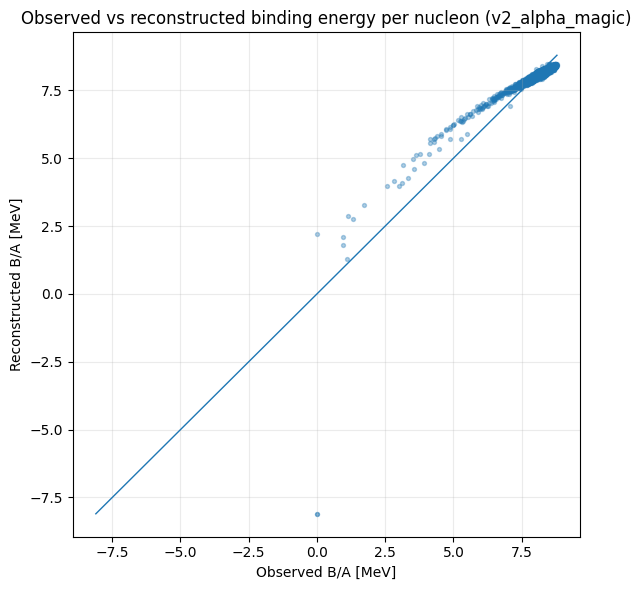

Saved: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/figures/fig02_observed_vs_reconstructed_all_nuclides.png


In [15]:
# CELL 12 — FIGURE 2: OBSERVED VS RECONSTRUCTED ALL NUCLIDES

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(work_pred["BE_per_A_MeV"], work_pred["BEA_pred_MeV"], s=8, alpha=0.35)
lo = min(work_pred["BE_per_A_MeV"].min(), work_pred["BEA_pred_MeV"].min())
hi = max(work_pred["BE_per_A_MeV"].max(), work_pred["BEA_pred_MeV"].max())
ax.plot([lo, hi], [lo, hi], linewidth=1)
ax.set_xlabel("Observed B/A [MeV]")
ax.set_ylabel("Reconstructed B/A [MeV]")
ax.set_title(f"Observed vs reconstructed binding energy per nucleon ({selected_model})")
ax.grid(True, alpha=0.25)
fig.tight_layout()
path = FIG / "fig02_observed_vs_reconstructed_all_nuclides.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig02_observed_vs_reconstructed_all_nuclides.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)


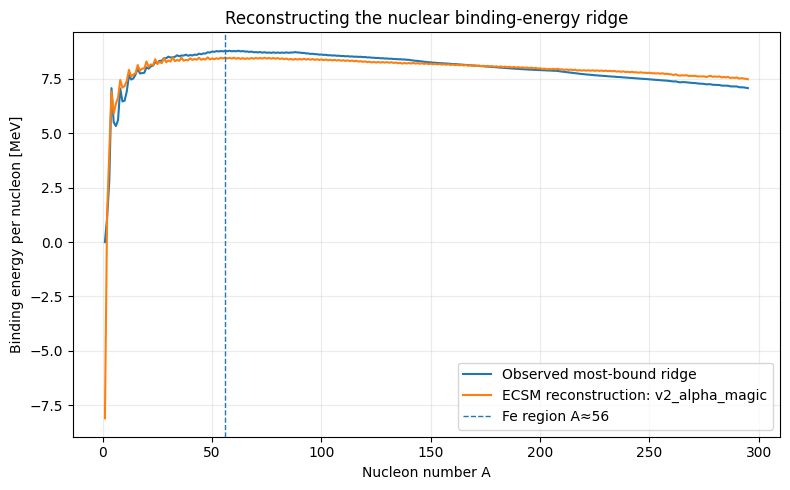

Saved: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/figures/fig03_binding_curve_reconstruction_v2.png


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
0,1,0,1,0.000000,0,1,-8.099921,8.099921,-8.099921
1,2,1,1,1.112283,1,1,1.287395,-1.287395,0.175111
2,3,1,2,2.827265,1,2,4.177549,-4.177549,1.350283
3,4,2,2,7.073916,2,2,6.920609,-6.920609,-0.153306
4,5,2,3,5.512132,2,3,5.903540,-5.903540,0.391408
5,6,3,3,5.332331,3,3,6.345785,-6.345785,1.013454
6,7,3,4,5.606440,3,4,6.637776,-6.637776,1.031335
7,8,4,4,7.062436,4,4,7.449367,-7.449367,0.386932
8,9,4,5,6.462669,4,5,7.100915,-7.100915,0.638246
9,10,4,6,6.497631,5,5,7.173165,-7.173165,0.675534


In [16]:
# CELL 13 — FIGURE 3: BINDING CURVE RECONSTRUCTION RIDGE

idx_pred = work_pred.groupby("A")["BEA_pred_MeV"].idxmax()
pred_ridge = work_pred.loc[idx_pred].sort_values("A").reset_index(drop=True)

merged_ridge = (
    ridge[["A", "Z", "N", "BE_per_A_MeV"]]
    .rename(columns={"Z":"Z_obs_ridge", "N":"N_obs_ridge", "BE_per_A_MeV":"BEA_obs_ridge_MeV"})
    .merge(
        pred_ridge[["A", "Z", "N", "BEA_pred_MeV", "response_cost_per_A_proxy"]]
        .rename(columns={"Z":"Z_pred_ridge", "N":"N_pred_ridge"}),
        on="A", how="inner"
    )
)
merged_ridge["ridge_residual_MeV"] = merged_ridge["BEA_pred_MeV"] - merged_ridge["BEA_obs_ridge_MeV"]
merged_ridge.to_csv(TAB / "ridge_observed_vs_ecsm_predicted_v2.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(merged_ridge["A"], merged_ridge["BEA_obs_ridge_MeV"], label="Observed most-bound ridge")
ax.plot(merged_ridge["A"], merged_ridge["BEA_pred_MeV"], label=f"ECSM reconstruction: {selected_model}")
ax.axvline(56, linestyle="--", linewidth=1, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Binding energy per nucleon [MeV]")
ax.set_title("Reconstructing the nuclear binding-energy ridge")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig03_binding_curve_reconstruction_v2.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig03_binding_curve_reconstruction_v2.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)
display(merged_ridge.head(20))


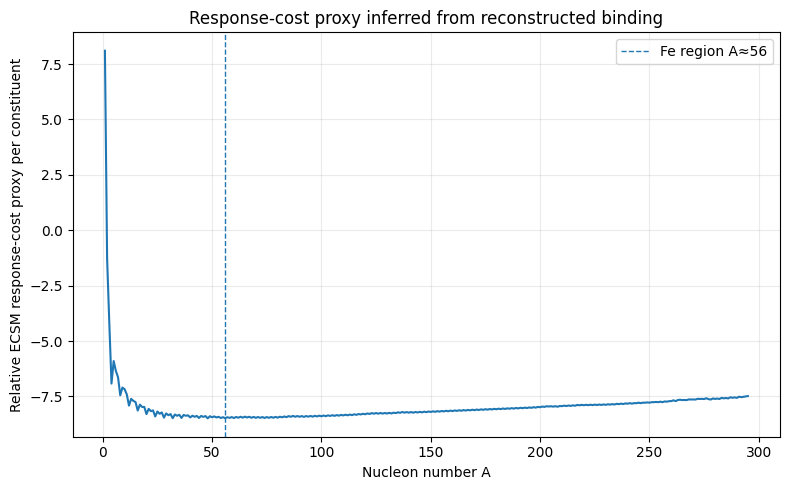

Saved: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/figures/fig04_response_cost_proxy_by_A_v2.png
Minimum response-cost proxy row:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
47,48.0,22.0,26.0,8.723012,24.0,24.0,8.488818,-8.488818,-0.234194


In [17]:
# CELL 14 — FIGURE 4: RESPONSE-COST PROXY AND IRON/NICKEL MINIMUM

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(merged_ridge["A"], merged_ridge["response_cost_per_A_proxy"])
ax.axvline(56, linestyle="--", linewidth=1, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Relative ECSM response-cost proxy per constituent")
ax.set_title("Response-cost proxy inferred from reconstructed binding")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig04_response_cost_proxy_by_A_v2.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig04_response_cost_proxy_by_A_v2.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)

min_row = merged_ridge.iloc[np.argmin(merged_ridge["response_cost_per_A_proxy"].to_numpy())]
print("Minimum response-cost proxy row:")
display(min_row.to_frame().T)


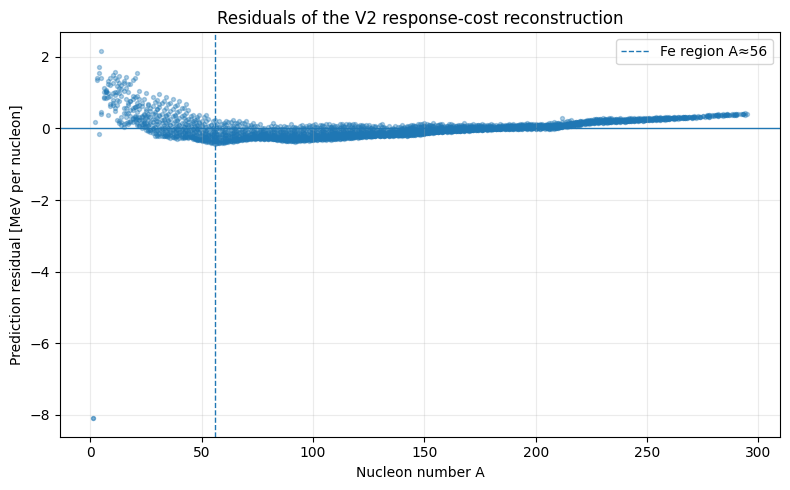

Saved: ecsm_binding_energy_reconstruction_v2_alpha_closure_out/figures/fig05_residuals_vs_A_v2.png


,A_band,n,rmse_MeV,mae_MeV,mean_residual_MeV
0,A<=4,8.0,4.190504,2.820125,-1.268763
1,5-20,98.0,0.904040,0.792477,0.792477
2,21-56,385.0,0.322923,0.249310,0.053758
3,57-120,904.0,0.222503,0.200164,-0.182693
4,>120,1981.0,0.153937,0.120350,0.041280


In [18]:
# CELL 15 — FIGURE 5: RESIDUALS BY A AND REGION SUMMARY

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(work_pred["A"], work_pred["residual_MeV"], s=8, alpha=0.35)
ax.axhline(0, linewidth=1)
ax.axvline(56, linestyle="--", linewidth=1, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Prediction residual [MeV per nucleon]")
ax.set_title("Residuals of the V2 response-cost reconstruction")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig05_residuals_vs_A_v2.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig05_residuals_vs_A_v2.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)

bins = [0, 4, 20, 56, 120, 300]
labels = ["A<=4", "5-20", "21-56", "57-120", ">120"]
work_pred["A_band"] = pd.cut(work_pred["A"], bins=bins, labels=labels, include_lowest=True)
band_summary = work_pred.groupby("A_band", observed=False).apply(
    lambda g: pd.Series({
        "n": len(g),
        "rmse_MeV": float(np.sqrt(mean_squared_error(g["BE_per_A_MeV"], g["BEA_pred_MeV"]))),
        "mae_MeV": float(mean_absolute_error(g["BE_per_A_MeV"], g["BEA_pred_MeV"])),
        "mean_residual_MeV": float(g["residual_MeV"].mean()),
    })
).reset_index()
band_summary.to_csv(TAB / "residual_summary_by_A_band_v2.csv", index=False)
display(band_summary)


In [19]:
# CELL 16 — V2 ALPHA / HELIUM CLOSURE DIAGNOSTIC TABLE

checkpoint_A = [1, 2, 3, 4, 8, 12, 16, 20, 28, 40, 56, 58, 60, 62, 120, 208, 238]
checkpoint = merged_ridge[merged_ridge["A"].isin(checkpoint_A)].copy()
checkpoint.to_csv(TAB / "checkpoint_nuclei_v2.csv", index=False)

print("Checkpoint nuclei:")
display(checkpoint)

print("Top observed B/A ridge nuclei:")
display(merged_ridge.sort_values("BEA_obs_ridge_MeV", ascending=False).head(15))

print("Top predicted B/A ridge nuclei:")
display(merged_ridge.sort_values("BEA_pred_MeV", ascending=False).head(15))


Checkpoint nuclei:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
0,1,0,1,0.000000,0,1,-8.099921,8.099921,-8.099921
1,2,1,1,1.112283,1,1,1.287395,-1.287395,0.175111
2,3,1,2,2.827265,1,2,4.177549,-4.177549,1.350283
3,4,2,2,7.073916,2,2,6.920609,-6.920609,-0.153306
7,8,4,4,7.062436,4,4,7.449367,-7.449367,0.386932
11,12,6,6,7.680145,6,6,7.914248,-7.914248,0.234104
15,16,8,8,7.976207,8,8,8.136509,-8.136509,0.160302
19,20,10,10,8.032241,10,10,8.298404,-8.298404,0.266163
27,28,14,14,8.447745,14,14,8.457151,-8.457151,0.009407
39,40,18,22,8.595259,20,20,8.446841,-8.446841,-0.148418


Top observed B/A ridge nuclei:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
61,62,28,34,8.794555,26,36,8.461146,-8.461146,-0.333410
57,58,26,32,8.792253,26,32,8.467975,-8.467975,-0.324278
55,56,26,30,8.790356,24,32,8.481837,-8.481837,-0.308520
59,60,28,32,8.780777,26,34,8.474131,-8.474131,-0.306646
53,54,24,30,8.777967,24,30,8.473724,-8.473724,-0.304243
63,64,28,36,8.777464,28,36,8.456103,-8.456103,-0.321361
51,52,24,28,8.775995,26,26,8.448140,-8.448140,-0.327855
56,57,26,31,8.770283,25,32,8.437897,-8.437897,-0.332386
58,59,27,32,8.768038,25,34,8.431660,-8.431660,-0.336378
60,61,28,33,8.765028,26,35,8.426504,-8.426504,-0.338524


Top predicted B/A ridge nuclei:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
47,48,22,26,8.723012,24,24,8.488818,-8.488818,-0.234194
55,56,26,30,8.790356,24,32,8.481837,-8.481837,-0.308520
31,32,16,16,8.493130,16,16,8.481766,-8.481766,-0.011364
59,60,28,32,8.780777,26,34,8.474131,-8.474131,-0.306646
53,54,24,30,8.777967,24,30,8.473724,-8.473724,-0.304243
43,44,20,24,8.658177,22,22,8.471539,-8.471539,-0.186638
73,74,32,42,8.725201,32,42,8.471049,-8.471049,-0.254152
35,36,16,20,8.575390,18,18,8.470146,-8.470146,-0.105244
57,58,26,32,8.792253,26,32,8.467975,-8.467975,-0.324278
75,76,34,42,8.711478,32,44,8.465484,-8.465484,-0.245995


In [20]:
# CELL 17 — EXPORT FIGURE ZIP, TABLE ZIP, AND VERDICT JSON

zip_path = OUT / "ecsm_binding_energy_v2_figures.zip"
with zipfile.ZipFile(zip_path, "w") as z:
    for file in FIG.glob("*"):
        z.write(file, arcname=file.name)

table_zip_path = OUT / "ecsm_binding_energy_v2_tables.zip"
with zipfile.ZipFile(table_zip_path, "w") as z:
    for file in TAB.glob("*"):
        z.write(file, arcname=file.name)

ridge_corr = float(np.corrcoef(merged_ridge["BEA_obs_ridge_MeV"], merged_ridge["BEA_pred_MeV"])[0, 1])
ridge_rmse = float(np.sqrt(np.mean((merged_ridge["BEA_pred_MeV"] - merged_ridge["BEA_obs_ridge_MeV"]) ** 2)))
pred_peak_A = int(merged_ridge.loc[merged_ridge["BEA_pred_MeV"].idxmax(), "A"])
obs_peak_A = int(merged_ridge.loc[merged_ridge["BEA_obs_ridge_MeV"].idxmax(), "A"])

helium_rows = work_pred[(work_pred.A == 4) & (work_pred.Z == 2) & (work_pred.N == 2)]
helium4_residual = None
helium4_pred = None
helium4_obs = None
if len(helium_rows):
    helium4_obs = float(helium_rows["BE_per_A_MeV"].iloc[0])
    helium4_pred = float(helium_rows["BEA_pred_MeV"].iloc[0])
    helium4_residual = helium4_pred - helium4_obs

light_rows = work_pred[work_pred.A <= 4]
light_rmse = float(np.sqrt(mean_squared_error(light_rows["BE_per_A_MeV"], light_rows["BEA_pred_MeV"])))

verdict = {
    "notebook": "ECSM_Binding_Energy_Reconstruction_V2_Alpha_Closure",
    "data_source": str(AME_CSV_PATH),
    "n_nuclides_used": int(len(work_pred)),
    "selected_model": selected_model,
    "model_metrics": results[selected_model]["metrics"],
    "model_selection_table": selection_table.to_dict(orient="records"),
    "ridge_corr": ridge_corr,
    "ridge_rmse_MeV_per_nucleon": ridge_rmse,
    "observed_ridge_peak_A": obs_peak_A,
    "predicted_ridge_peak_A": pred_peak_A,
    "helium4_observed_BEA_MeV": helium4_obs,
    "helium4_predicted_BEA_MeV": helium4_pred,
    "helium4_residual_MeV": helium4_residual,
    "light_A_le_4_rmse_MeV": light_rmse,
    "qualitative_pass_flags": {
        "positive_ridge_correlation": bool(ridge_corr > 0),
        "peak_near_iron_region": bool(40 <= pred_peak_A <= 75),
        "ridge_rmse_below_2_MeV": bool(ridge_rmse < 2.0),
        "helium4_residual_below_1p5_MeV": bool(helium4_residual is not None and abs(helium4_residual) < 1.5),
    },
    "exports": {
        "figure_zip": str(zip_path),
        "table_zip": str(table_zip_path),
        "verdict_json": str(OUT / "binding_curve_v2_verdict.json"),
    },
}

with open(OUT / "binding_curve_v2_verdict.json", "w") as f:
    json.dump(verdict, f, indent=2)

print("=" * 72)
print("ECSM BINDING CURVE V2 — ALPHA / HELIUM CLOSURE VERDICT")
print("=" * 72)
print(json.dumps(verdict, indent=2))
print()
print("Saved:")
print(zip_path)
print(table_zip_path)
print(OUT / "binding_curve_v2_verdict.json")


ECSM BINDING CURVE V2 — ALPHA / HELIUM CLOSURE VERDICT
{
  "notebook": "ECSM_Binding_Energy_Reconstruction_V2_Alpha_Closure",
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_nuclides_used": 3376,
  "selected_model": "v2_alpha_magic",
  "model_metrics": {
    "train": {
      "rmse_MeV": 0.3472062707059365,
      "mae_MeV": 0.18788736936381992,
      "corr": 0.8884752320609781,
      "r2": 0.789388237985809
    },
    "test": {
      "rmse_MeV": 0.23973832821842317,
      "mae_MeV": 0.16622379350382085,
      "corr": 0.9776421033370433,
      "r2": 0.8066856421886177
    },
    "all": {
      "rmse_MeV": 0.32309502461506007,
      "mae_MeV": 0.18233671974329288,
      "corr": 0.8909023916986932,
      "r2": 0.7920467922200848
    }
  },
  "model_selection_table": [
    {
      "model": "base",
      "rmse_MeV": 0.23721521226499664,
      "mae_MeV": 0.16850899900780805,
      "corr": 0.9755957017712404,
      "r2": 0.8107332875338789,
      "ridge_corr": 0.8413817297640278,
 

## Interpretation notes

Use the final verdict conservatively.

A good V2 result is not proof of an ECSM nuclear theory. It means the response-cost scaffold can qualitatively recover the broad AME2020 binding-energy ridge while testing whether explicit alpha/helium closure terms improve the light-nucleus sector.

Paper-ready claims should distinguish:

- **empirical ridge recovery**: whether the iron/Ni maximum is recovered;
- **light-sector recovery**: whether hydrogen, deuterium, tritium/helium-3, and helium-4 are handled better than V1;
- **model status**: response-cost reconstruction, not a first-principles derivation yet.
